# Example Core Scalar Surface

Canonical core-scalar example notebook for the `arb_core`, `acb_core`, `arf`, `acf`, `fmpr`, `fmpzi`, and `arb_fpwrap` public surfaces.

## Scope

This notebook is the canonical example surface for `example_core_scalar_surface`. It runs against the repo source tree through `/src`, shows direct public API usage, summarizes validation and benchmark status, and includes visual summaries.

In [1]:
import json
import os
import subprocess
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'arbplusjax').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)

PYTHON = os.getenv('ARBPLUSJAX_PYTHON', sys.executable)
JAX_MODE = os.getenv('JAX_MODE', 'cpu').strip().lower()
JAX_DTYPE = os.getenv('JAX_DTYPE', 'float64').strip().lower()
RUN_ENV = os.environ.copy()
RUN_ENV['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + RUN_ENV.get('PYTHONPATH', '')
if JAX_MODE == 'cpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cpu'
elif JAX_MODE == 'gpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cuda'
RUN_ENV['JAX_ENABLE_X64'] = '1' if JAX_DTYPE == 'float64' else '0'
EXAMPLE_INPUT_ROOT = REPO_ROOT / 'examples' / 'inputs' / 'example_core_scalar_surface'
EXAMPLE_OUTPUT_ROOT = REPO_ROOT / 'examples' / 'outputs' / 'example_core_scalar_surface'
EXAMPLE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def run(cmd: list[str], *, capture: bool = False):
    print('[cmd]', ' '.join(cmd))
    return subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=capture, check=True)


## Environment

The notebook reports interpreter, selected JAX mode, and the active backend/device view.

In [2]:
print('python:', PYTHON)
print('jax_mode:', JAX_MODE)
print('jax_dtype:', JAX_DTYPE)
runtime = run([PYTHON, 'tools/check_jax_runtime.py'], capture=True)
print(runtime.stdout)
runtime_payload = json.loads(runtime.stdout)
(EXAMPLE_OUTPUT_ROOT / f'runtime_{JAX_MODE}.json').write_text(json.dumps(runtime_payload, indent=2) + '\n', encoding='utf-8')

python: /home/phili/miniforge3/envs/jax/bin/python
jax_mode: cpu
jax_dtype: float64
[cmd] /home/phili/miniforge3/envs/jax/bin/python tools/check_jax_runtime.py


{
  "platform": "cpu",
  "devices": [
    "TFRT_CPU_0"
  ],
  "jax_enable_x64": true,
  "env": {
    "JAX_PLATFORM_NAME": "",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "",
    "XLA_PYTHON_CLIENT_MEM_FRACTION": "",
    "XLA_FLAGS": ""
  }
}



235

## Object/Input Construction

Construct representative real intervals, complex boxes, floating arrays, integer-interval arrays, and fpwrap point inputs.

In [3]:
import jax.numpy as jnp
from arbplusjax import acb_core, api, double_interval as di

real_interval = di.interval(jnp.array([0.2, 0.5, 1.0], dtype=jnp.float64), jnp.array([0.25, 0.6, 1.1], dtype=jnp.float64))
complex_box = acb_core.acb_box(
    di.interval(jnp.array([0.2, 0.4], dtype=jnp.float64), jnp.array([0.25, 0.5], dtype=jnp.float64)),
    di.interval(jnp.array([-0.2, 0.1], dtype=jnp.float64), jnp.array([-0.1, 0.2], dtype=jnp.float64)),
)
float_a = jnp.array([1.0, 2.0, 3.0], dtype=jnp.float32)
float_b = jnp.array([0.5, 1.5, 2.5], dtype=jnp.float32)
complex_a = jnp.array([1.0 + 0.5j, 2.0 - 0.25j], dtype=jnp.complex64)
int_interval_a = jnp.array([[1, 2], [3, 5], [8, 13]], dtype=jnp.int64)
int_interval_b = jnp.array([[2, 3], [5, 8], [13, 21]], dtype=jnp.int64)
fpwrap_real = jnp.array([0.1, 0.4, 0.9], dtype=jnp.float32)
display({'real_interval_shape': real_interval.shape, 'complex_box_shape': complex_box.shape})

{'real_interval_shape': (3, 2), 'complex_box_shape': (2, 4)}

## Direct Usage

Run the public API directly on representative core scalar families.

In [4]:
results = {
    'arb_exp_basic': api.eval_interval('arb_exp', real_interval, mode='basic', dtype='float64'),
    'acb_sin_basic': api.eval_interval('acb_sin', complex_box, mode='basic', dtype='float64'),
    'arf_add': api.eval_point('arf_add', float_a, float_b),
    'acf_mul': api.eval_point('acf_mul', complex_a, complex_a),
    'fmpr_mul': api.eval_point('fmpr_mul', float_a, float_b),
    'fmpzi_add': api.eval_point('fmpzi_add', int_interval_a, int_interval_b),
    'arb_fpwrap_double_exp': api.eval_point('arb_fpwrap_double_exp', fpwrap_real),
}
display(results)

{'arb_exp_basic': Array([[1.22140276, 1.28402542],
        [1.64872127, 1.8221188 ],
        [2.71828183, 3.00416602]], dtype=float64),
 'acb_sin_basic': Array([[ 0.22562102,  0.22562102, -0.14676805, -0.14676805],
        [ 0.43986808,  0.43986808,  0.13557414,  0.13557414]],      dtype=float64),
 'arf_add': Array([1.5, 3.5, 5.5], dtype=float32),
 'acf_mul': Array([0.75  +1.j, 3.9375-1.j], dtype=complex64),
 'fmpr_mul': Array([0.5, 3. , 7.5], dtype=float32),
 'fmpzi_add': Array([[ 3,  5],
        [ 8, 13],
        [21, 34]], dtype=int64),
 'arb_fpwrap_double_exp': Array([1.105171 , 1.4918246, 2.459603 ], dtype=float32)}

## Parameter/Value Sweeps

Sweep representative scalar families over values and modes using the existing harness profile.

In [5]:
profile_dir = EXAMPLE_OUTPUT_ROOT / ('cpu_profile' if JAX_MODE == 'cpu' else 'gpu_profile')
run([
    PYTHON, 'benchmarks/run_harness_profile.py',
    '--name', f'example_core_scalar_{JAX_MODE}',
    '--outdir', str(profile_dir),
    '--functions', 'exp,log,sqrt,sin,cos,tan,sinh,cosh,tanh',
    '--samples', '64,128',
    '--seeds', '0,1',
    '--jax-mode', JAX_MODE,
    '--jax-dtype', JAX_DTYPE,
    '--prec-bits', '128',
])
profile_csv = profile_dir / 'profile_summary.csv'
profile_df = pd.read_csv(profile_csv)
display(profile_df.head(20))

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/run_harness_profile.py --name example_core_scalar_cpu --outdir /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile --functions exp,log,sqrt,sin,cos,tan,sinh,cosh,tanh --samples 64,128 --seeds 0,1 --jax-mode cpu --jax-dtype float64 --prec-bits 128


[run] sweep samples=64,128 seeds=0,1 functions=exp,log,sqrt,sin,cos,tan,sinh,cosh,tanh
Wrote results to /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile


Wrote: /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile/profile_summary.csv
Wrote: /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile/profile_summary.md


,function,backend,samples,mean_abs_err,max_abs_err,containment_rate,mean_width,time_ms,notes,sweep_sample,sweep_seed,wall_s,peak_rss_mb,run_dir
0,sqrt,c_arb,64,NaN,NaN,NaN,1.036980e-06,0.089311,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
1,sqrt,jax_basic,64,1.647990e-17,2.220450e-16,0.0,1.036980e-06,0.510738,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
2,sqrt,jax_adaptive,64,9.563350e-13,4.129160e-11,0.0,1.036990e-06,0.377396,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
3,sqrt,jax_rigorous,64,9.563350e-13,4.129160e-11,0.0,1.036990e-06,0.439916,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
4,sqrt,scipy,64,9.563350e-13,4.129160e-11,1.0,NaN,0.014712,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
5,sqrt,jax_point,64,9.563350e-13,4.129160e-11,1.0,NaN,0.277631,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
6,sqrt,mpmath,64,9.563350e-13,4.129160e-11,1.0,NaN,0.372749,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
7,sqrt,boost,64,9.563350e-13,4.129160e-11,1.0,NaN,7.920860,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
8,tanh,c_arb,64,NaN,NaN,NaN,8.579620e-07,0.119636,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...
9,tanh,jax_basic,64,7.253400e-17,2.220450e-16,0.0,8.579620e-07,0.455005,NaN,64,0,6.149111,659.777344,/home/phili/projects/arbplusJAX/examples/outpu...


## Validation Summary

Run the existing scalar chassis/API tests and summarize the result.

In [6]:
tests = run([
    PYTHON, '-m', 'pytest', '-q',
    'tests/test_core_scalar_api_contracts.py',
    'tests/test_arb_core_chassis.py',
    'tests/test_acb_core_chassis.py',
    'tests/test_arf_chassis.py',
    'tests/test_acf_chassis.py',
    'tests/test_fmpr_chassis.py',
    'tests/test_fmpzi_chassis.py',
    'tests/test_arb_fpwrap_chassis.py',
], capture=True)
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
(EXAMPLE_OUTPUT_ROOT / f'pytest_{JAX_MODE}.txt').write_text(tests.stdout + ('\n' + tests.stderr if tests.stderr else ''), encoding='utf-8')

[cmd] /home/phili/miniforge3/envs/jax/bin/python -m pytest -q tests/test_core_scalar_api_contracts.py tests/test_arb_core_chassis.py tests/test_acb_core_chassis.py tests/test_arf_chassis.py tests/test_acf_chassis.py tests/test_fmpr_chassis.py tests/test_fmpzi_chassis.py tests/test_arb_fpwrap_chassis.py


..........................                                               [100%]
26 passed in 19.09s



100

## Benchmark Summary

Run representative scalar benchmark entrypoints and summarize cold/warm/recompile behavior.

In [7]:
bench_dir = EXAMPLE_OUTPUT_ROOT / 'benchmark_artifacts'
bench_dir.mkdir(parents=True, exist_ok=True)
run([PYTHON, 'benchmarks/benchmark_arf.py', '--samples', '4096', '--which', 'add', '--runs', '3', '--output', str(bench_dir / 'benchmark_arf.json')])
run([PYTHON, 'benchmarks/benchmark_arb_fpwrap.py', '--samples', '4096', '--which', 'exp', '--runs', '3', '--output', str(bench_dir / 'benchmark_arb_fpwrap.json')])
run([PYTHON, 'benchmarks/benchmark_acf.py', '--samples', '4096', '--which', 'mul', '--runs', '3', '--output', str(bench_dir / 'benchmark_acf.json')])
run([PYTHON, 'benchmarks/benchmark_fmpr.py', '--samples', '4096', '--which', 'mul', '--runs', '3', '--output', str(bench_dir / 'benchmark_fmpr.json')])
run([PYTHON, 'benchmarks/benchmark_fmpzi.py', '--samples', '4096', '--which', 'add', '--runs', '3', '--output', str(bench_dir / 'benchmark_fmpzi.json')])
bench_payloads = []
for path in sorted(bench_dir.glob('*.json')):
    payload = json.loads(path.read_text())
    for row in payload['records']:
        bench_payloads.append(row)
bench_df = pd.DataFrame(bench_payloads)
bench_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'benchmark_summary_{JAX_MODE}.csv', index=False)
display(bench_df[['operation', 'cold_time_s', 'warm_time_s', 'recompile_time_s']])

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_arf.py --samples 4096 --which add --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_arf.json


arf (add) | samples=4096 | warm_time_ms=0.19
[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_arb_fpwrap.py --samples 4096 --which exp --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_arb_fpwrap.json


arb_fpwrap (rexp) | samples=4096 | warm_time_ms=0.02
[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_acf.py --samples 4096 --which mul --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_acf.json


acf (mul) | samples=4096 | warm_time_ms=0.15
[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_fmpr.py --samples 4096 --which mul --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_fmpr.json


fmpr (mul) | samples=4096 | warm_time_ms=0.15
[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_fmpzi.py --samples 4096 --which add --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_fmpzi.json


fmpzi (add) | samples=4096 | warm_time_ms=0.23


,operation,cold_time_s,warm_time_s,recompile_time_s
0,acf_mul,0.055128,0.000147,0.028701
1,arb_fpwrap_double_exp,0.054900,0.000016,0.030297
2,arf_add,0.065172,0.000187,0.031082
3,fmpr_mul,0.157379,0.000152,0.034737
4,fmpzi_add,0.080489,0.000230,0.056026


## Comparison Summary

Where reference software is available, use the existing compare scripts. If local C reference libraries are absent, note that explicitly.

In [8]:
compare_cmds = [
    [PYTHON, 'benchmarks/compare_arb_core.py', '--samples', '256', '--output', str(EXAMPLE_OUTPUT_ROOT / 'compare_arb_core.json')],
    [PYTHON, 'benchmarks/compare_acb_core.py', '--samples', '256', '--output', str(EXAMPLE_OUTPUT_ROOT / 'compare_acb_core.json')],
]
comparison_rows = []
for cmd in compare_cmds:
    try:
        completed = subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=True, check=True)
        print(completed.stdout)
        comparison_rows.append({'script': cmd[1], 'status': 'ok', 'stdout': completed.stdout[-2000:], 'stderr': completed.stderr[-2000:]})
    except subprocess.CalledProcessError as exc:
        print('comparison unavailable or failed for', cmd[1])
        print(exc.stdout)
        print(exc.stderr)
        comparison_rows.append({'script': cmd[1], 'status': 'failed_or_unavailable', 'stdout': (exc.stdout or '')[-2000:], 'stderr': (exc.stderr or '')[-2000:]})
(EXAMPLE_OUTPUT_ROOT / f'comparison_status_{JAX_MODE}.json').write_text(json.dumps(comparison_rows, indent=2) + '\n', encoding='utf-8')

arb_exp          | ok=True | max_abs_diff=4.547e-13
arb_log          | ok=True | max_abs_diff=0.000e+00
arb_sqrt         | ok=True | max_abs_diff=0.000e+00
arb_sin          | ok=True | max_abs_diff=0.000e+00
arb_cos          | ok=True | max_abs_diff=0.000e+00
arb_tan          | ok=True | max_abs_diff=0.000e+00
arb_sinh         | ok=True | max_abs_diff=4.547e-13
arb_cosh         | ok=True | max_abs_diff=4.547e-13
arb_tanh         | ok=True | max_abs_diff=4.441e-16

result: PASS



acb_exp          | ok=True | max_abs_diff=3.553e-15
acb_log          | ok=True | max_abs_diff=2.220e-16
acb_sqrt         | ok=True | max_abs_diff=1.467e-14
acb_sin          | ok=True | max_abs_diff=7.105e-15
acb_cos          | ok=True | max_abs_diff=1.421e-14
acb_tan          | ok=True | max_abs_diff=1.066e-14
acb_sinh         | ok=True | max_abs_diff=1.421e-14
acb_cosh         | ok=True | max_abs_diff=1.421e-14
acb_tanh         | ok=True | max_abs_diff=1.776e-15

result: PASS



1213

## Plots

Plot backend timing and containment summaries from the harness profile.

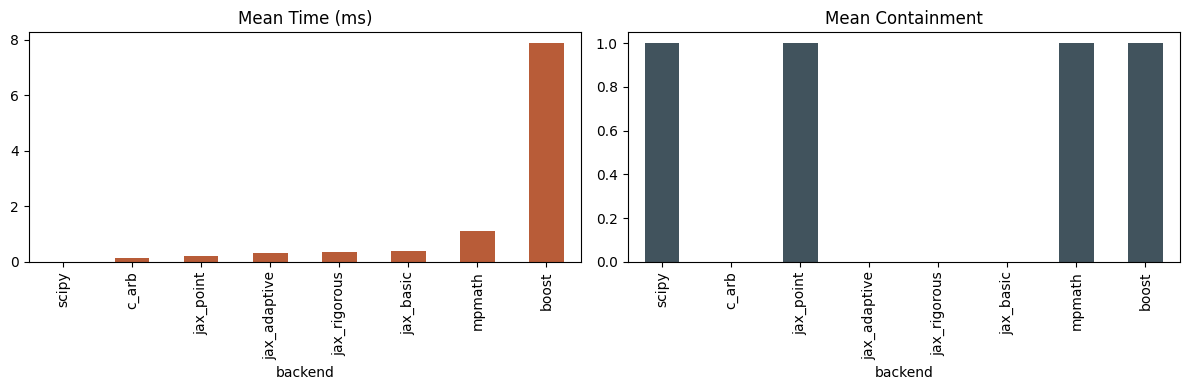

In [9]:
plot_df = profile_df.copy()
for col in ['time_ms', 'containment_rate', 'mean_abs_err']:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')
summary = plot_df.groupby('backend', dropna=False)[['time_ms', 'containment_rate']].mean(numeric_only=True).sort_values('time_ms')
summary.to_csv(EXAMPLE_OUTPUT_ROOT / f'profile_backend_summary_{JAX_MODE}.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary['time_ms'].plot(kind='bar', ax=axes[0], title='Mean Time (ms)', color='#b85c38')
summary['containment_rate'].plot(kind='bar', ax=axes[1], title='Mean Containment', color='#41535d')
fig.tight_layout()
fig.savefig(EXAMPLE_OUTPUT_ROOT / f'profile_backend_summary_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Optional Diagnostics

Use the matrix/compile diagnostics tools only when compile traces or memory deltas are needed. The scalar tranche here keeps those optional.

In [10]:
summary_lines = [
    f'# Example Core Scalar Surface Summary ({JAX_MODE})',
    '',
    f'- python: `{PYTHON}`',
    f'- backend: `{runtime_payload["platform"]}`',
    f'- devices: `{runtime_payload["devices"]}`',
    f'- benchmark_rows: `{len(bench_df)}`',
    f'- profile_rows: `{len(profile_df)}`',
    f'- comparison_rows: `{len(comparison_rows)}`',
    '',
    '## Benchmark Operations',
    '',
]
for op in sorted(set(bench_df['operation'].tolist())):
    summary_lines.append(f'- `{op}`')
summary_lines.extend(['', '## Backend Summary', ''])
for row in summary.reset_index().to_dict(orient='records'):
    summary_lines.append(f"- `{row['backend']}`: mean_time_ms={row['time_ms']:.6g}, mean_containment={row['containment_rate']:.6g}")
(EXAMPLE_OUTPUT_ROOT / f'summary_{JAX_MODE}.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
display('\n'.join(summary_lines[:16]))

"# Example Core Scalar Surface Summary (cpu)\n\n- python: `/home/phili/miniforge3/envs/jax/bin/python`\n- backend: `cpu`\n- devices: `['TFRT_CPU_0']`\n- benchmark_rows: `5`\n- profile_rows: `288`\n- comparison_rows: `2`\n\n## Benchmark Operations\n\n- `acf_mul`\n- `arb_fpwrap_double_exp`\n- `arf_add`\n- `fmpr_mul`\n- `fmpzi_add`"